# 5. Prefix Caching

By [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)) and [Claude Code](https://claude.com/claude-code) 🤖

The last three lectures treated prefill as work that has to be done: it is
compute-bound (lecture 1), it interferes with decoding (lecture 3), and we can
either chunk it or move it to its own GPUs (lecture 4). This lecture is about
the work we can avoid doing at all.

## Why the same tokens arrive over and over

A language model is a pure function of the tokens you hand it. The server keeps
nothing between requests: once your answer has finished streaming, the request's
KV cache is freed and, as far as the GPU is concerned, the conversation never
happened. Continuity is an illusion maintained by the *client*, which re-sends
the entire history every time you press enter.

So a two-message chat is not two small requests. It is one small request and one
large one, and what actually goes over the wire looks like this:

```text
request 1   [system prompt, ~1,000 tokens]
            [user: "How do I reverse a list in Python?"]

request 2   [system prompt, ~1,000 tokens]            <- identical
            [user: "How do I reverse a list in Python?"]   <- identical
            [assistant: "Use list.reverse(), or ..."]      <- identical
            [user: "What about a tuple?"]                  <- new
```

The **system prompt** is the block of text the application puts in front of every
conversation and never shows you: who the assistant is supposed to be, what it
must refuse to do, today's date, the JSON schema of every tool it may call, and
often a handful of examples of good answers. In a serious application it is not
short — several hundred to a few thousand tokens, and for an agent carrying a
dozen tool definitions, much more (lecture 6).

The second request has to carry the first exchange because the model cannot see
it otherwise: "What about a tuple?" is meaningless without the question and the
answer above it. By the fifth turn, the request opens with four turns of history,
and every one of those tokens was computed on this very GPU a minute ago and then
thrown away.

### The same text also repeats across users

Repetition is not confined to one conversation. *Every* user of an application
sends that same system prompt, so the opening thousand tokens of every request
the deployment receives are token-for-token identical. A support assistant pastes
the same product manual into the prompt for everyone who asks about it; a coding
assistant sends the same repository files; a classifier sends the same twenty
few-shot examples in front of each new input.

Those users have nothing to do with each other, and they can still share one copy
of the prefix. In a busy deployment this is often the larger prize: a popular
prompt opening is re-sent thousands of times a minute, by strangers, and only the
last few hundred tokens of each request differ. It also makes the *order* in
which an application assembles its prompt a performance decision, and it raises a
fair question about what two strangers sharing memory implies for isolation. We
measure the first and discuss the second later in the lecture.

## The idea

**Prefix caching** keeps that KV cache — the per-token keys and values every
later token attends to (lecture 2) — around after a request finishes, and reuses
it. If a new prompt starts with tokens whose KV is still in GPU memory, those
tokens are not prefilled again; the model starts computing at the first token it
has never seen. It costs nothing in accuracy: the KV of a token depends only on
the tokens before it, so a reused block holds exactly the values a fresh prefill
would have produced.

:::{admonition} Learning goals
- Explain how a KV cache is addressed by block hashes, and why reuse works only
  on a *prefix*.
- Measure the effect of prefix caching on prefill work and TTFT, both within one
  conversation and across users who share a long preamble.
- Explain the two things that destroy a hit: eviction under memory pressure, and
  a request landing on a replica that does not hold the prefix.
- Lay out a prompt so that it is cache-friendly, and say what cross-user sharing
  costs as well as what it buys.
:::

## Setup

Same system as lectures 3 and 4: Qwen2.5-32B-Instruct, one replica on two A100s.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/faculty/kvm6242/.llm-systems-wo-gpus/backend


## How a prefix cache works

The KV cache is not one contiguous array per request. It is a pool of fixed-size
**blocks** (16 tokens each here), handed out to requests as they grow — this is
*paged attention*, and it is what lets a replica pack many requests of different
lengths into memory without fragmenting it.

Prefix caching adds one idea on top: **give every full block a name, and keep a
table from names to blocks.** The name is a hash of

```text
hash(block) = H( hash(previous block), the 16 token ids in this block )
```

so a block's name depends on its own tokens *and* on the entire history before
it. Two requests get the same name for their 5th block only if their first 80
tokens are identical.

When a request arrives, the scheduler hashes its prompt block by block and looks
each name up, stopping at the first miss. Everything before the miss is a **hit**:
those blocks are reused (their reference count goes up, so they cannot be
evicted while in use) and the request is prefilled starting from the first
uncached token.

```text
  turn 1 prompt   [sys ][sys ][user1]                 3 blocks computed,
                                     [ans1]           1 more filled while decoding
  turn 2 prompt   [sys ][sys ][user1][ans1][user2]    4 hits, 1 block computed
```

Note that the answer's blocks are reusable too: they were written during turn 1's
decode and named like any other, which is why turn 2 reuses the previous answer
as well as the previous prompt.

Three properties follow, and all three matter in practice:

1. **Matching is on a prefix, not on a substring.** The chained hash means one
   different token early in the prompt gives every later block a different name,
   even if the rest of the text is identical. Shared text that comes *after*
   something variable is not reusable.
2. **The last, partial block is not named.** Only full blocks are hashed, so
   hits are rounded down to a multiple of the block size.
3. **A hit requires the block to still exist, on that GPU.** The pool is finite
   and shared with the running requests, so cached blocks are evicted under
   memory pressure; and each replica has its own pool, so the request has to be
   routed to the replica that holds the prefix.

The simulator implements exactly this scheme. It needs to know the *token ids* of
each request to compute the hashes, so the traces in this lecture carry a
`token_ids` column; a trace with only lengths (lectures 1–4) can never produce a
hit. Prefix caching is off by default and switched on with
`lsg.simulate(prefix_caching=True)`.

## A multi-turn workload

Let's build a trace of conversations. Each session is a user and an assistant
taking turns: a 200-token user message, a 200-token answer, then another user
message appended to everything that came before, and so on. Turn *k+1* is
released only after turn *k* finishes (`dep`), plus a **think time** standing in
for the human reading the answer.

The token ids themselves are random, which is the point: two requests share a
prefix only when we make them literally identical.

In [2]:
rng = np.random.default_rng(0)
def toks(n):
    """n token ids that appear nowhere else (so nothing matches by accident)."""
    return rng.integers(10, 150_000, n).tolist()

def chat_trace(n_sessions=24, n_turns=6, question=200, answer=200, preamble=0,
               preamble_first=True, think=5.0, name=None):
    """Multi-turn conversations, optionally sharing a `preamble`-token system prompt."""
    shared = toks(preamble)
    rows = []
    for s in range(n_sessions):
        context = []
        for t in range(n_turns):
            user = toks(question)
            # Turn 0 starts the conversation; later turns append to the context.
            context = (shared + user if preamble_first else user + shared) if t == 0 \
                      else context + user
            reply = toks(answer)
            rows.append(dict(prefill=len(context), decode=answer, ids=context + reply,
                             session=s, turn=t, dep=[] if t == 0 else [t - 1],
                             think=0.0 if t == 0 else think, rid=1000 * s + t))
            context = context + reply    # the next turn sees this answer too
    df = pd.DataFrame(rows)
    path = lsg.make_trace(df.prefill, df.decode, len(df), name=name, token_ids=df.ids,
                          session_id=df.session, turn_id=df.turn, dep=df.dep,
                          think_time=df.think, request_id=df.rid)
    return path, df

chat, chat_df = chat_trace()
chat_df[["session", "turn", "prefill", "decode", "think"]].head(7)

,session,turn,prefill,decode,think
0,0,0,200,200,0.0
1,0,1,600,200,5.0
2,0,2,1000,200,5.0
3,0,3,1400,200,5.0
4,0,4,1800,200,5.0
5,0,5,2200,200,5.0
6,1,0,200,200,0.0


Turn 0 prefills 200 tokens, and every later turn 400 more than the one before:
the user's new message plus the assistant's previous answer. Only those 400
tokens are new; everything else was computed on this replica seconds ago.

## Does it help?

Run the same trace with prefix caching off and on.

In [3]:
def run(trace, df, **kwargs):
    return lsg.simulate(**SYSTEM, trace=trace, num_requests=len(df), **kwargs)

cols = ["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "throughput (tok/s)", "makespan (s)"]
runs = {f"prefix caching {'on' if pc else 'off'}": run(chat, chat_df, qps=1.0, prefix_caching=pc)
        for pc in (False, True)}
pd.DataFrame({k: {**r.summary()[cols], "prompt tokens computed": r.requests["request_num_prefill_tokens"].sum()
                                       - r.requests["request_num_prefill_tokens_cached"].sum(),
                  "hit rate": r.cache_hit_rate}
              for k, r in runs.items()}).round(2)

,prefix caching off,prefix caching on
TTFT p50 (ms),351.94,84.54
TTFT p99 (ms),1966.43,123.36
TPOT p50 (ms),49.08,40.22
throughput (tok/s),1738.30,1949.51
makespan (s),115.98,103.41
prompt tokens computed,172800.00,28800.00
hit rate,0.00,0.83


83% of all prompt tokens never reach the GPU. The median TTFT falls from about
350 ms to 85 ms, and the tail by a factor of sixteen: a cache hit removes most
of the queueing too, because the prefill it skips would otherwise have delayed
every request behind it.

TPOT improves as well, for the reason lecture 3 gave: shorter prefills mean
fewer steps that carry a big prefill chunk alongside the decodes.

The gain is not spread evenly over the conversation. Let's look per turn.

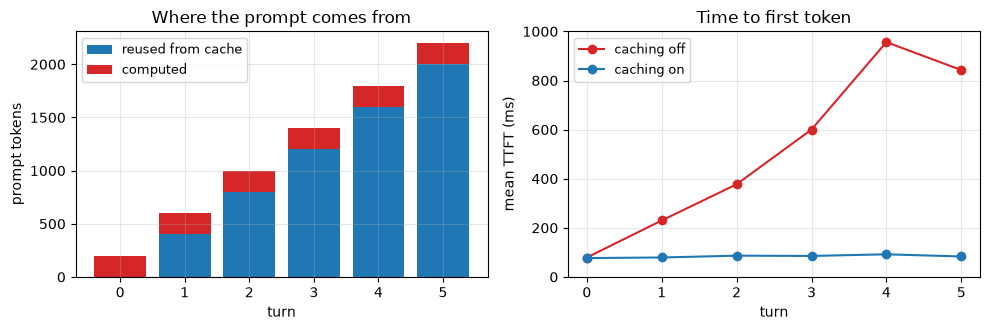

In [4]:
hit = runs["prefix caching on"].requests.copy()
hit["turn"] = hit["Request Id"] % 1000
per_turn = hit.groupby("turn").agg(prompt=("request_num_prefill_tokens", "mean"),
                                   cached=("request_num_prefill_tokens_cached", "mean"),
                                   ttft=("prefill_e2e_time", "mean"))
miss = runs["prefix caching off"].requests.copy()
miss["turn"] = miss["Request Id"] % 1000
per_turn["ttft_off"] = miss.groupby("turn")["prefill_e2e_time"].mean()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].bar(per_turn.index, per_turn["cached"], label="reused from cache", color="C0")
ax[0].bar(per_turn.index, per_turn["prompt"] - per_turn["cached"],
          bottom=per_turn["cached"], label="computed", color="C3")
ax[0].set(xlabel="turn", ylabel="prompt tokens", title="Where the prompt comes from")
ax[1].plot(per_turn.index, 1e3 * per_turn["ttft_off"], "o-", color="C3", label="caching off")
ax[1].plot(per_turn.index, 1e3 * per_turn["ttft"], "o-", color="C0", label="caching on")
ax[1].set(xlabel="turn", ylabel="mean TTFT (ms)", title="Time to first token", ylim=(0, None))
for a in ax:
    a.legend(fontsize=9)
fig.tight_layout()

Without caching, a conversation gets more expensive with every turn: the prompt
grows, so TTFT grows. With caching, the *computed* part of the prompt is flat —
always the 400 new tokens — and so is TTFT. This is the single most important
consequence of prefix caching: **the cost of a turn stops depending on how long
the conversation already is.**

(Turn 0 is the exception. Its prompt is new, so it is a full miss, and it is the
only turn whose TTFT the cache cannot improve.)

## Prompt layout: where the shared text goes

Now the cross-user case from the introduction. These 60 requests belong to 60
different users with nothing in common except the application they are talking
to — no conversation history to reuse, and the first user to arrive gets no help
from the cache at all. What they share is the preamble the application prepends:
system prompt, tool definitions, few-shot examples.

We give them a shared preamble of 0, 512, or 2,048 tokens, placed either before
the user's question or after it. The text is the same in both cases; only the
order differs.

In [5]:
layout = {}
for preamble in (0, 512, 2048):
    for first in (True, False):
        if preamble == 0 and not first:
            continue
        tr, df = chat_trace(n_sessions=60, n_turns=1, question=200, answer=100,
                            preamble=preamble, preamble_first=first)
        r = run(tr, df, qps=2.0, prefix_caching=True)
        label = f"{preamble}-token preamble" + ("" if first else ", after the question")
        layout[label] = {"prompt tokens": int(r.requests["request_num_prefill_tokens"].mean()),
                         "hit rate": r.cache_hit_rate,
                         **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)"]]}
pd.DataFrame(layout).T.round(2)

,prompt tokens,hit rate,TTFT p50 (ms),TTFT p99 (ms)
0-token preamble,200.0,0.00,78.50,104.78
512-token preamble,712.0,0.71,80.45,140.43
"512-token preamble, after the question",712.0,0.00,192.88,389.20
2048-token preamble,2248.0,0.90,84.22,322.48
"2048-token preamble, after the question",2248.0,0.00,1461.36,3726.36


With the preamble first, 90% of the prompt tokens are shared and the median TTFT
barely moves as the preamble grows from nothing to 2,048 tokens: one request pays
for the preamble and the other 59 read its KV cache. Nobody had to arrange this —
the users never interact, and the application did not ask for any of it. Two
requests sharing an opening is all it takes.

Move the identical text behind the user's question and the hit rate is exactly
zero. The first block already differs between users, so the chained hash gives
every later block a different name too, and a 2,048-token preamble now costs a
17× higher median TTFT than the same preamble placed first.

:::{note}
This is the practical rule for anyone *writing* prompts for a served
application: **most stable first, most variable last**. System prompt, tool
definitions, and retrieved documents that change rarely go at the top; the
user's turn goes at the bottom. A timestamp or a session id at the start of a
system prompt is enough to disable sharing between users entirely.
:::

## The cache is finite

Cached blocks live in the same pool as the KV cache of the *running* requests.
When a replica needs a block and none is free, it evicts the least recently used
cached block — a prefix someone might have come back to.

Our replica holds about 350,000 tokens of KV cache, far more than this small
workload needs, which is why nothing was evicted above. Real replicas are not so
comfortable: they run hundreds of concurrent requests with long contexts. We can
emulate that pressure by shrinking the pool with `kv_blocks` (the number of
16-token blocks) and watching a 40-session workload, whose live context is about
90,000 tokens, fit in less and less memory.

In [6]:
chat40, chat40_df = chat_trace(n_sessions=40, n_turns=6, think=10.0, name="chat40")
cache_sweep = {}
for blocks in (3000, 4000, 5000, 6000, 7000, 8000):
    r = run(chat40, chat40_df, qps=2.0, prefix_caching=True, kv_blocks=blocks)
    cache_sweep[blocks * 16] = {"hit rate": r.cache_hit_rate,
                                "evictions": int(r.cache.loc[0, "evictions"]),
                                **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)"]]}
cache_sweep = pd.DataFrame(cache_sweep).T.rename_axis("KV cache (tokens)")
cache_sweep.round(2)

,hit rate,evictions,TTFT p50 (ms),TTFT p99 (ms)
KV cache (tokens),,,,
48000,0.37,14907.0,127.32,7065.17
64000,0.42,10611.0,98.89,3802.96
80000,0.60,5338.0,91.31,2486.91
96000,0.83,95.0,88.33,212.01
112000,0.83,0.0,88.33,212.01
128000,0.83,0.0,88.33,212.01


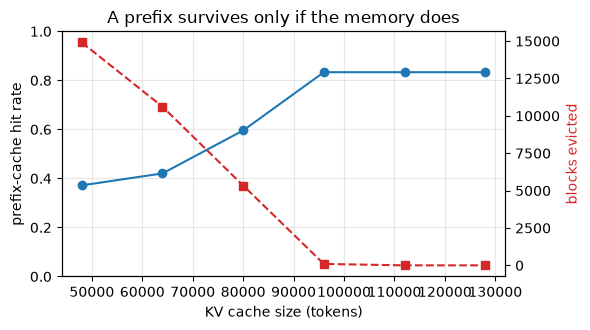

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(cache_sweep.index, cache_sweep["hit rate"], "o-", color="C0")
ax.set(xlabel="KV cache size (tokens)", ylabel="prefix-cache hit rate", ylim=(0, 1))
ax2 = ax.twinx()
ax2.plot(cache_sweep.index, cache_sweep["evictions"], "s--", color="C3")
ax2.set_ylabel("blocks evicted", color="C3")
ax2.grid(False)
ax.set_title("A prefix survives only if the memory does")
fig.tight_layout()

Above about 96,000 tokens of KV cache — enough to hold every live session's
history — eviction all but stops and the hit rate is the full 83%. Below it, blocks
are thrown away between turns and have to be recomputed: at 48,000 tokens the
hit rate has fallen to 37%, and the tail TTFT is tens of times worse, because
evicted sessions re-prefill their whole history and preempt each other while
doing it.

The practical reading: **a prefix cache is a bet that the conversation comes
back before the memory is needed.** Hit rates in production depend as much on
how long users take to reply and how loaded the replica is as on the prompts
themselves. Systems that want the bet to pay off more often spill evicted blocks
to CPU memory or SSD rather than dropping them, which the simulator also models
(`enable_disk_caching`).

## The cache is per-replica

One replica cannot see another's KV cache. If turn 2 of a conversation is routed
to a different GPU than turn 1, the prefix is on the wrong machine and the
request is a full miss.

Let's run the same conversations on a cluster of four replicas with different
routing policies: `round_robin` (ignore history, spread the load),
`sticky_lor` (pin each session, on its first request, to the least-loaded replica
and send every later turn of it there), and `dynamo_kv` (a Dynamo-style router
that scores each replica by the prompt tokens it would still have to compute
*plus* its current decode load).

In [8]:
routing = {}
for policy in ("round_robin", "sticky_lor", "dynamo_kv"):
    r = run(chat40, chat40_df, qps=8.0, num_replicas=4, prefix_caching=True,
            global_scheduler=policy)
    routing[policy] = {"hit rate": r.cache_hit_rate,
                       **r.summary()[["TTFT p50 (ms)", "TTFT p99 (ms)", "throughput (tok/s)"]]}
pd.DataFrame(routing).T.round(2)

,hit rate,TTFT p50 (ms),TTFT p99 (ms),throughput (tok/s)
round_robin,0.39,98.58,1413.65,3226.42
sticky_lor,0.83,79.20,113.01,3291.83
dynamo_kv,0.64,93.94,1050.45,3212.77


Round-robin cuts the hit rate to less than half, and its tail TTFT is an order of
magnitude worse than the affinity-aware policies. The lesson is that prefix
caching is not purely a replica-local optimisation: **it changes what the
cluster's router should do.** Sending a request to the least-loaded replica is
the right move when every replica would have to prefill the prompt from scratch,
and the wrong one when a particular replica can skip 80% of it.

That trade-off — cache affinity against load balance — is the subject of
{doc}`08-cluster-routing`.

## What prefix caching does not do

- **It does not speed up decode.** Only prompt tokens can be reused; the answer
  still has to be generated one token at a time, at the memory-bound speed of
  lecture 1. In a workload that is mostly generation, prefix caching changes
  little.
- **It is not free in memory.** Blocks held for a prefix that may never be
  reused are blocks unavailable to running requests. Under heavy load a system
  that caches too eagerly reduces its own batch size.
- **It changes the shape of the load, not just its size.** With most prefills
  skipped, the replica becomes more decode-dominated, which changes the right
  chunk size (lecture 3) and the right prefill:decode split (lecture 4).
- **Cross-user sharing cuts both ways.** The experiment above worked precisely
  because two strangers' requests touched the same blocks, and that is where much
  of the benefit of a shared system prompt comes from. But a hit is also faster
  than a miss in a way anyone can measure: from its own TTFT, a request can tell
  whether the prefix it just sent was already in the cache, and therefore whether
  *someone else* recently sent the same opening. That is a known timing side
  channel, and it matters when the shared opening is not public — a tenant's
  confidential system prompt, or a document pasted in front of a question.
  Deployments that care give each tenant (or each user) its own cache namespace
  and share only a prefix they have declared public, and they pay for that
  isolation in hit rate.

## Summary

| | Effect |
|---|---|
| What is reused | KV blocks of a matching **prefix**, named by a chained hash of their tokens |
| Biggest win | later turns of one conversation, and long openings (system prompt, tool definitions, pasted documents) shared across *different* users |
| Who shares | anyone whose prompt starts with the same tokens, by accident or by design; no coordination needed, and no isolation either |
| Effect on TTFT | the computed part of the prompt stops growing with the conversation |
| Effect on TPOT / decode | indirect only (fewer and shorter prefill chunks per step) |
| Killed by | variable text placed before shared text; eviction under memory pressure; routing to another replica |
| Interacts with | router policy (affinity vs. load), chunk size, KV-cache capacity |

## Exercises

:::{admonition} Try it
:class: exercise
Each exercise asks you to change code above and rerun it. Write down your
prediction *before* you run.

1. **Longer conversations.** Rerun the first experiment with `n_turns=12`. Does
   the hit rate go up or down? What happens to the gap between the two TTFT
   curves at the last turn, and why?
2. **Block granularity.** `chat_trace` writes `block_size=16`. Rebuild the trace
   with `block_size=256` (pass it through `lsg.make_trace`) and compare hit rates.
   Which workload loses more from coarse blocks: the multi-turn one or the shared
   preamble one?
3. **A nearly-shared preamble.** Change `chat_trace` so that each session's
   preamble ends with 8 session-specific tokens (a user id, say) while the first
   2,040 tokens stay identical. Predict the hit rate, then measure it. Now move
   those 8 tokens to the *front* of the preamble and measure again.
4. **Does caching change the best chunk size?** Repeat lecture 3's `chunk_size`
   sweep (128, 512, 2048) on `chat40` with caching off and on. Does the best
   chunk size move?
:::

## Check your understanding

Click an answer to check it. Wrong answers can be retried.

In [9]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "Why does reusing a cached KV block not change the model's output?",
     "options": ["The error is small enough to ignore",
                 "A token's keys and values depend only on the tokens before it, so the cached values are exactly what a fresh prefill would compute",
                 "The cache is only used for tokens the model has already answered about"],
     "answer": 1,
     "explain": "Attention is causal: the KV of token i is a function of tokens 0..i. If the prefix is identical, the KV is identical."},
    {"q": "Two prompts are identical except for a session id in the <b>first</b> 10 tokens. How much do they share in the cache?",
     "options": ["Everything after the session id", "Nothing", "Half"], "answer": 1,
     "explain": "A block's hash chains in the hash of the previous block, so a difference anywhere early gives every later block a different name."},
    {"q": "In the multi-turn experiment, which turn benefits least from prefix caching?",
     "options": ["The first turn", "The last turn", "All turns benefit equally"], "answer": 0,
     "explain": "Turn 0's prompt has never been seen, so it is a full miss. Later turns reuse everything up to the previous answer."},
    {"q": "An application puts a timestamp at the top of its system prompt. What is the likely effect?",
     "options": ["Nothing; the timestamp is tiny",
                 "The hit rate across users collapses, because the shared text that follows now hashes differently for every request",
                 "TPOT gets worse"],
     "answer": 1,
     "explain": "Size is irrelevant: it is position that matters. Variable text at the top invalidates the prefix for everything after it."},
    {"q": "Why did the hit rate fall when we shrank the KV cache?",
     "options": ["Smaller caches hash blocks differently",
                 "Cached blocks are evicted to make room for running requests, so a returning turn no longer finds its prefix",
                 "Prefix caching turns itself off below a memory threshold"],
     "answer": 1,
     "explain": "Cached prefixes and live requests share one pool. Under pressure the least recently used cached blocks are evicted, and the next turn has to recompute them."},
    {"q": "Why does round-robin routing lower the hit rate in a multi-replica cluster?",
     "options": ["It overloads one replica",
                 "Each replica has its own KV cache, so a turn routed elsewhere cannot see the prefix its session built",
                 "It disables prefix caching"],
     "answer": 1,
     "explain": "Caches are per-GPU. Affinity-aware routing (sticky or KV-aware) sends a session back to the replica that holds its history."},
    {"q": "A workload has 200-token prompts and 2,000-token answers. How much should prefix caching help?",
     "options": ["A lot: 2,200 tokens are cached",
                 "Very little: almost all the work is decode, which prefix caching cannot skip"],
     "answer": 1,
     "explain": "Only prompt tokens can be reused. Prefix caching pays off when prompts are long and repetitive, which is exactly the agentic workload of the next lecture."},
])